CSV columns found: ['X', 'Y', 'Z', 'Scalar field']
Using X='X', Y='Y'

Trajectory: 516 points, total length = 265.6 m
Station range: 0.0 m  →  265.6 m

Loading LiDAR...
  Sidewalk raw:  5,853 pts
  Lane raw:      123,560 pts
  Sidewalk after voxel: 5,763 pts
  Lane after voxel:     122,376 pts

KD-Trees built.

At S_TARGET=90 m:
  Trajectory point p = [ 332099.1606979 5933642.5195313]
  Estimated heading  t_hat = [ 0.99946043 -0.03284577]
  Right-side normal  n_hat = [-0.03284577 -0.99946043]


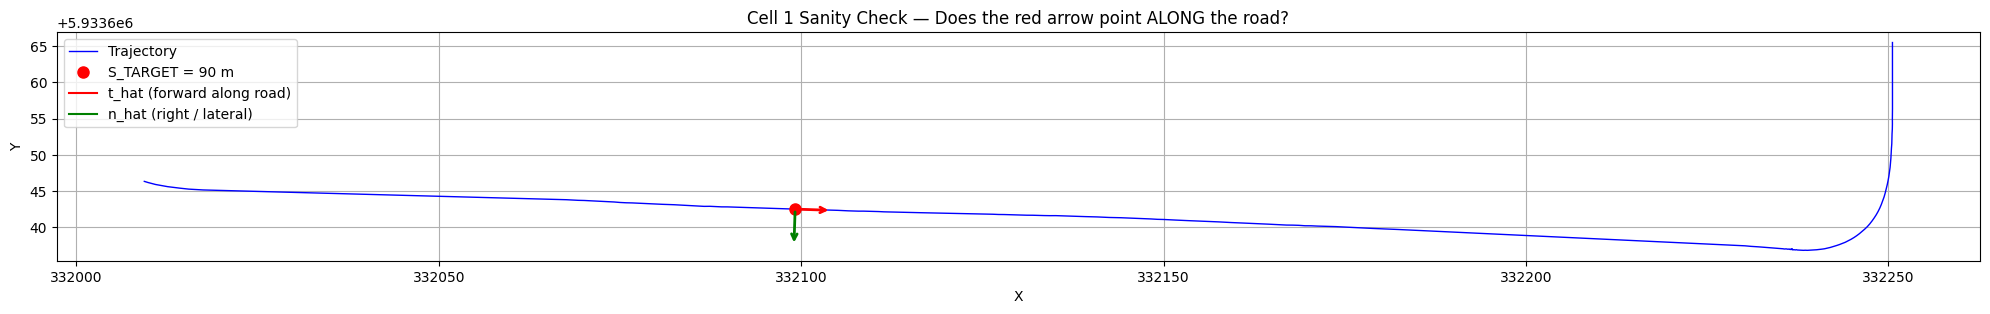

In [ ]:
# ============================================================
# CELL 1 — Load Data & Verify Trajectory Direction
# ============================================================
# PURPOSE:
#   Load trajectory CSV + both LAS files, build the station
#   ruler (cumulative distance), and draw a sanity-check plot
#   so we can confirm the heading arrow points the right way
#   before any cross-section work.
#
# EXPECTED OUTPUT:
#   - Printed column names of your CSV
#   - Printed trajectory length in metres
#   - A 2D plot of the trajectory with an arrow at S_TARGET
#     showing the estimated heading direction.
#   If the arrow points ALONG the road → Cell 1 passed.
#   If the arrow points SIDEWAYS       → X/Y columns are swapped.
# ============================================================

import numpy as np
import pandas as pd
import laspy
from sklearn.neighbors import KDTree
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# FILE PATHS  ← edit these
# ─────────────────────────────────────────
SIDEWALK_LAS = r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\sidewalk.las"
LANE_LAS     = r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\lane2.las"
TRAJ_CSV     = r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\20250506_R01_506_Trg.csv"

# ─────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────
S_TARGET        = 90   # station (m) to inspect first
HEADING_WINDOW  = 35.0    # ± metres used to average heading
VOXEL           = 0.001    # voxel grid size (m) for downsampling
HALF_THICK_U    = 0.3     # half-thickness of the cross-section slab (m)
V_MIN, V_MAX    = -30, 30 # lateral window (m)
QUERY_RADIUS    = 35.0    # KD-tree search radius (m)


# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────

def load_trajectory(csv_path: str) -> tuple[np.ndarray, str, str]:
    """
    Load a trajectory CSV and auto-detect Easting (X) and Northing (Y) columns.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.

    Returns
    -------
    traj_xy : np.ndarray, shape (N, 2)
        Array of [Easting, Northing] for each trajectory sample.
    xcol, ycol : str
        The detected column names for X and Y.

    Example
    -------
    >>> traj_xy, xcol, ycol = load_trajectory("lidar_trj.csv")
    >>> print(traj_xy.shape)   # (N, 2)
    """
    df = pd.read_csv(csv_path)
    print("CSV columns found:", list(df.columns))

    cand_x = ["utm_e", "easting", "Easting", "east", "x", "X", "pos_x", "px", "lon", "Lon"]
    cand_y = ["utm_n", "northing", "Northing", "north", "y", "Y", "pos_y", "py", "lat", "Lat"]

    xcol = next((c for c in cand_x if c in df.columns), None)
    ycol = next((c for c in cand_y if c in df.columns), None)

    if xcol is None or ycol is None:
        raise ValueError(
            f"Could not auto-detect X/Y columns.\n"
            f"Available: {list(df.columns)}\n"
            f"Set xcol/ycol manually."
        )

    print(f"Using X='{xcol}', Y='{ycol}'")
    traj_xy = df[[xcol, ycol]].to_numpy(float)
    return traj_xy, xcol, ycol, df


def build_station_ruler(traj_xy: np.ndarray) -> np.ndarray:
    """
    Compute cumulative arc-length (station) along the trajectory.

    s[0] = 0
    s[i] = s[i-1] + ||p[i] - p[i-1]||

    Parameters
    ----------
    traj_xy : np.ndarray, shape (N, 2)

    Returns
    -------
    s : np.ndarray, shape (N,)
        Cumulative distance in metres at each trajectory sample.

    Example
    -------
    >>> s = build_station_ruler(traj_xy)
    >>> print(f"Total length: {s[-1]:.1f} m")
    """
    diffs  = np.diff(traj_xy, axis=0)          # (N-1, 2) step vectors
    dists  = np.linalg.norm(diffs, axis=1)      # (N-1,)   step lengths
    s      = np.zeros(len(traj_xy), dtype=float)
    s[1:]  = np.cumsum(dists)
    return s


def compute_heading(traj_xy: np.ndarray,
                    s: np.ndarray,
                    idx: int,
                    window_m: float) -> np.ndarray | None:
    """
    Estimate a stable heading unit vector at trajectory index `idx`
    by averaging step-vectors within ±window_m metres.

    This smooths out GPS jitter that would otherwise cause the
    cross-section slab to rotate wildly from one step to the next.

    Parameters
    ----------
    traj_xy  : np.ndarray, shape (N, 2)
    s        : np.ndarray, shape (N,)   cumulative distance
    idx      : int                      target index
    window_m : float                    smoothing half-window (metres)

    Returns
    -------
    t_hat : np.ndarray, shape (2,)  unit vector, or None if not computable.

    Example
    -------
    >>> t_hat = compute_heading(traj_xy, s, idx=500, window_m=35.0)
    >>> print(t_hat)   # e.g. [0.707, 0.707]  (NE direction)
    """
    s0 = s[idx] - window_m
    s1 = s[idx] + window_m
    i0 = max(0,            int(np.searchsorted(s, s0, side="left")))
    i1 = min(len(s) - 1,   int(np.searchsorted(s, s1, side="right")) - 1)

    if i1 - i0 < 2:
        return None

    steps = traj_xy[i0 + 1 : i1 + 1] - traj_xy[i0 : i1]  # (K, 2)
    norms = np.linalg.norm(steps, axis=1)
    steps = steps[norms > 1e-9]

    if len(steps) == 0:
        return None

    mean_dir = np.mean(steps, axis=0)
    length   = np.linalg.norm(mean_dir)
    if length < 1e-12:
        return None

    return mean_dir / length   # t_hat


def read_las_xyz(path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Read X, Y, Z arrays from a LAS/LAZ file.

    Parameters
    ----------
    path : str

    Returns
    -------
    x, y, z : np.ndarray  (float64)

    Example
    -------
    >>> x, y, z = read_las_xyz("Sidewalk.las")
    >>> print(len(x), "points")
    """
    las = laspy.read(path)
    return np.asarray(las.x), np.asarray(las.y), np.asarray(las.z)


def voxel_downsample(x: np.ndarray,
                     y: np.ndarray,
                     z: np.ndarray,
                     voxel: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Keep one representative point per voxel cell (grid-based downsampling).
    Reduces memory and speeds up KD-tree queries without losing geometric structure.

    Parameters
    ----------
    x, y, z : np.ndarray
    voxel   : float   grid cell size in metres (e.g. 0.05 for 5 cm)

    Returns
    -------
    x, y, z : np.ndarray  (downsampled)

    Example
    -------
    >>> x, y, z = voxel_downsample(x, y, z, voxel=0.05)
    """
    pts  = np.column_stack([x, y, z])
    keys = np.floor(pts / voxel).astype(np.int64)
    _, idx = np.unique(keys, axis=0, return_index=True)
    pts  = pts[idx]
    return pts[:, 0], pts[:, 1], pts[:, 2]


# ─────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────

# 1. Load trajectory
traj_xy, xcol, ycol, dfT = load_trajectory(TRAJ_CSV)
s = build_station_ruler(traj_xy)
print(f"\nTrajectory: {len(traj_xy)} points, total length = {s[-1]:.1f} m")
print(f"Station range: {s[0]:.1f} m  →  {s[-1]:.1f} m")

# 2. Load + downsample LiDAR
print("\nLoading LiDAR...")
sx, sy, sz = read_las_xyz(SIDEWALK_LAS)
lx, ly, lz = read_las_xyz(LANE_LAS)
print(f"  Sidewalk raw:  {len(sx):,} pts")
print(f"  Lane raw:      {len(lx):,} pts")

sx, sy, sz = voxel_downsample(sx, sy, sz, VOXEL)
lx, ly, lz = voxel_downsample(lx, ly, lz, VOXEL)
print(f"  Sidewalk after voxel: {len(sx):,} pts")
print(f"  Lane after voxel:     {len(lx):,} pts")

# Build KD-Trees (done once, reused in all later cells)
side_xy   = np.column_stack([sx, sy])
lane_xy   = np.column_stack([lx, ly])
side_tree = KDTree(side_xy)
lane_tree = KDTree(lane_xy)
print("\nKD-Trees built.")

# 3. Sanity-check plot: trajectory + heading arrow at S_TARGET
idx_check = int(np.argmin(np.abs(s - S_TARGET)))
p_check   = traj_xy[idx_check]
t_check   = compute_heading(traj_xy, s, idx_check, HEADING_WINDOW)

print(f"\nAt S_TARGET={S_TARGET} m:")
print(f"  Trajectory point p = {p_check}")
print(f"  Estimated heading  t_hat = {t_check}")

if t_check is not None:
    n_check = np.array([t_check[1], -t_check[0]])   # 90° right of heading
    print(f"  Right-side normal  n_hat = {n_check}")

fig, ax = plt.subplots(figsize=(20, 12))
ax.plot(traj_xy[:, 0], traj_xy[:, 1], "b-", linewidth=1, label="Trajectory")
ax.plot(*p_check, "ro", markersize=8, label=f"S_TARGET = {S_TARGET} m")

arrow_scale = 5.0   # metres — make this bigger if arrow is invisible
if t_check is not None:
    ax.annotate(
        "", 
        xy    = p_check + t_check * arrow_scale,
        xytext= p_check,
        arrowprops=dict(arrowstyle="->", color="red", lw=2)
    )
    ax.annotate(
        "",
        xy    = p_check + n_check * arrow_scale,
        xytext= p_check,
        arrowprops=dict(arrowstyle="->", color="green", lw=2)
    )
    ax.plot([], [], "r-",  label="t_hat (forward along road)")
    ax.plot([], [], "g-",  label="n_hat (right / lateral)")

ax.set_aspect("equal")
ax.legend()
ax.set_title("Cell 1 Sanity Check — Does the red arrow point ALONG the road?")
ax.set_xlabel(xcol)
ax.set_ylabel(ycol)
ax.grid(True)
plt.tight_layout()
plt.show()

Station s ≈ 89.96 m  |  p = [ 332099.1606979 5933642.5195313]  |  t_hat = [ 0.99946043 -0.03284577]
Lane points:     657
Sidewalk points: 101


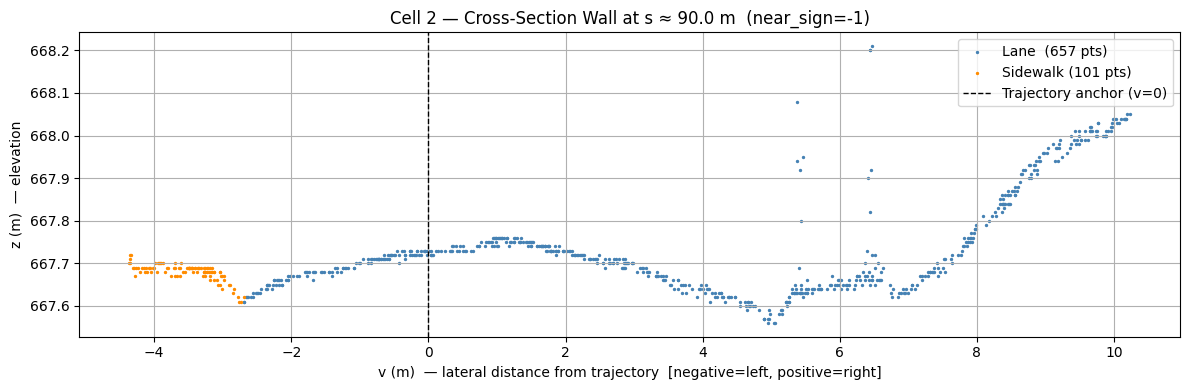

In [2]:
# ============================================================
# CELL 2 — Single Cross-Section Extraction & Visual Check
# ============================================================
# PURPOSE:
#   Extract the 2D (v, z) "wall" profile at one station and
#   plot it. Confirm lane and sidewalk points appear on the
#   correct sides before running the full corridor loop.
#
# REQUIRES: Cell 1 to have been run (traj_xy, s, side_tree,
#           lane_tree, sx/sy/sz, lx/ly/lz all in memory).
#
# EXPECTED OUTPUT:
#   Scatter plot:
#     - Blue  = lane points
#     - Orange = sidewalk points
#     - Black dashed line at v=0 (trajectory anchor)
#   Lane and sidewalk should appear as a recognizable
#   road cross-section shape (flat lane, then curb/ramp, 
#   then raised sidewalk).
# ============================================================


def extract_cross_section(xy_pts:   np.ndarray,
                           z_pts:    np.ndarray,
                           tree:     KDTree,
                           p:        np.ndarray,
                           t_hat:    np.ndarray,
                           half_u:   float,
                           v_min:    float,
                           v_max:    float,
                           query_r:  float
                           ) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract points from a thin slab perpendicular to the road at point p.

    Steps
    -----
    1. Radius query  : grab all points within query_r metres of p.
    2. Local frame   : rotate to (u=along-road, v=lateral) coordinates.
    3. Slab filter   : keep only points where |u| ≤ half_u  (thin wall)
                       AND  v_min ≤ v ≤ v_max  (lateral window).

    Parameters
    ----------
    xy_pts  : (M, 2) world XY of the point cloud
    z_pts   : (M,)   elevation of the point cloud
    tree    : KDTree built on xy_pts
    p       : (2,)   world XY of the cross-section anchor
    t_hat   : (2,)   unit heading vector (along road)
    half_u  : float  slab half-thickness in metres (e.g. 0.3)
    v_min   : float  left  lateral limit (e.g. -30)
    v_max   : float  right lateral limit (e.g.  30)
    query_r : float  KD-tree search radius (e.g. 35)

    Returns
    -------
    v : (K,)  lateral coordinate of kept points
    z : (K,)  elevation of kept points

    Example
    -------
    >>> v_lane, z_lane = extract_cross_section(
    ...     lane_xy, lz, lane_tree,
    ...     p, t_hat,
    ...     half_u=0.3, v_min=-30, v_max=30, query_r=35.0
    ... )
    """
    # Step 1 — radius bucket
    ids = tree.query_radius(p.reshape(1, -1), r=query_r)[0]
    if len(ids) == 0:
        return np.array([]), np.array([])

    # Step 2 — local coordinate transform
    rel   = xy_pts[ids] - p          # vectors from p to each point
    u     = rel @ t_hat              # along-road component
    n_hat = np.array([t_hat[1], -t_hat[0]])   # 90° clockwise = right side
    v     = rel @ n_hat              # lateral component

    # Step 3 — slab + lateral filter
    mask  = (np.abs(u) <= half_u) & (v >= v_min) & (v <= v_max)
    return v[mask], z_pts[ids][mask]


def orient_cross_section(v_lane_raw: np.ndarray,
                          v_side_raw: np.ndarray
                          ) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Flip lateral coordinates so lane is always on the positive-v side.
    This makes plots consistent regardless of which side of the road
    the trajectory was recorded on.

    Parameters
    ----------
    v_lane_raw : lateral coords of lane points (before flip)
    v_side_raw : lateral coords of sidewalk points (before flip)

    Returns
    -------
    v_lane : flipped lane v
    v_side : flipped sidewalk v
    sign   : +1.0 or -1.0  (stored for later reconstruction)

    Example
    -------
    >>> v_lane, v_side, sign = orient_cross_section(v_lane_raw, v_side_raw)
    """
    if len(v_lane_raw) == 0:
        sign = 1.0
    else:
        sign = 1.0 if np.median(v_lane_raw) >= 0 else -1.0
    return v_lane_raw * sign, v_side_raw * sign, sign


# ─────────────────────────────────────────
# SINGLE-STATION TEST
# ─────────────────────────────────────────

# Find trajectory point at S_TARGET
idx   = int(np.argmin(np.abs(s - S_TARGET)))
p     = traj_xy[idx]
t_hat = compute_heading(traj_xy, s, idx, HEADING_WINDOW)

if t_hat is None:
    raise RuntimeError(f"Cannot compute heading at S_TARGET={S_TARGET}. Try a different value.")

print(f"Station s ≈ {s[idx]:.2f} m  |  p = {p}  |  t_hat = {t_hat}")

# Extract raw (v, z) for both clouds
v_lane_raw, z_lane = extract_cross_section(
    lane_xy, lz, lane_tree, p, t_hat,
    HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
)
v_side_raw, z_side = extract_cross_section(
    side_xy, sz, side_tree, p, t_hat,
    HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
)

# Orient so lane is on positive side
v_lane, v_side, near_sign = orient_cross_section(v_lane_raw, v_side_raw)

print(f"Lane points:     {len(v_lane)}")
print(f"Sidewalk points: {len(v_side)}")

# ─────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(v_lane, z_lane, s=2, c="steelblue",  label=f"Lane  ({len(v_lane)} pts)")
ax.scatter(v_side, z_side, s=2, c="darkorange", label=f"Sidewalk ({len(v_side)} pts)")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Trajectory anchor (v=0)")

ax.set_xlabel("v (m)  — lateral distance from trajectory  [negative=left, positive=right]")
ax.set_ylabel("z (m)  — elevation")
ax.set_title(f"Cell 2 — Cross-Section Wall at s ≈ {s[idx]:.1f} m  (near_sign={near_sign:+.0f})")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Running corridor loop: 532 stations  (step=0.5 m) ...
Done. 532 stations stored, 0 skipped (no heading).
Building corridor map ...


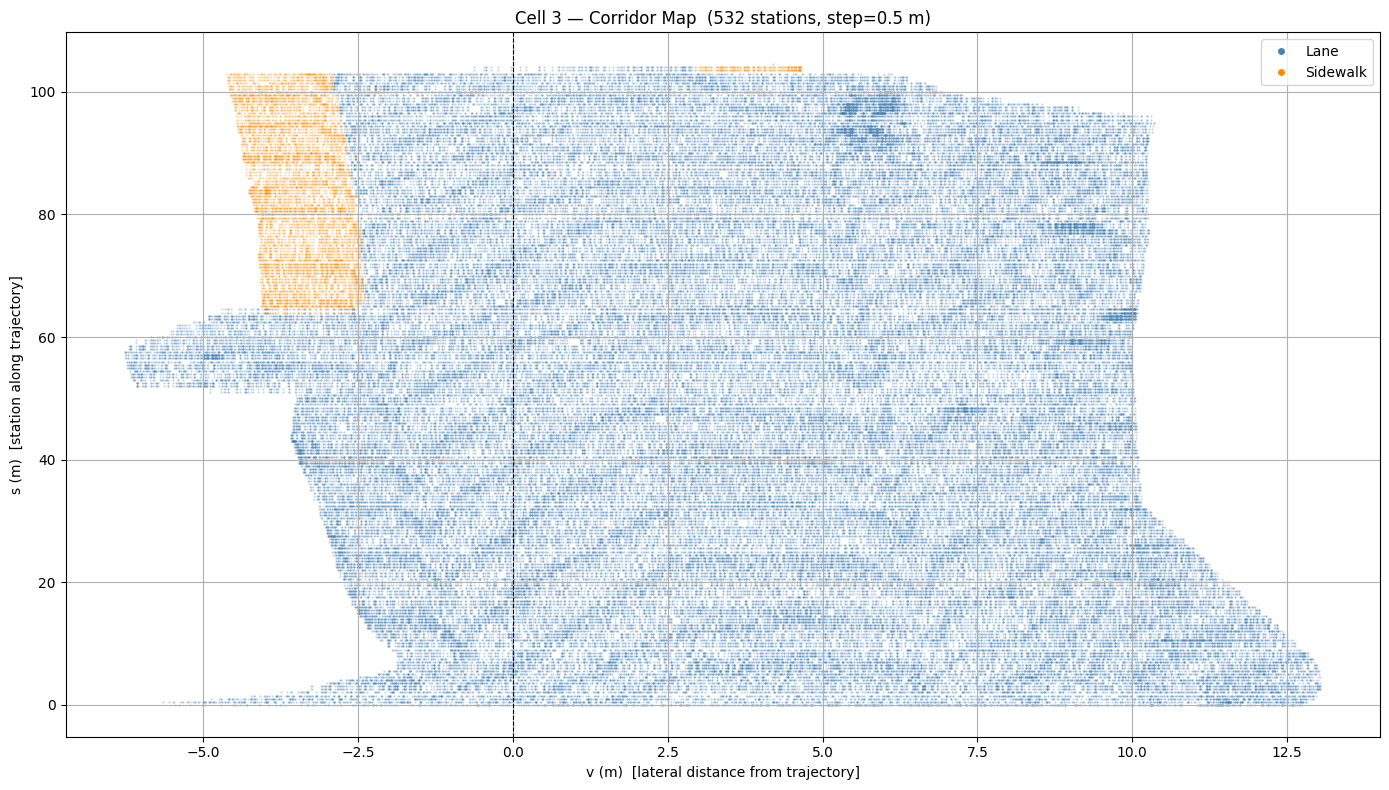

In [3]:
# ============================================================
# CELL 3 — Full Corridor Loop  (builds `results`)
# ============================================================
# PURPOSE:
#   Run cross-section extraction at every 0.1 m station along
#   the entire trajectory and store the raw (v, z) slices.
#   This is the data-collection pass — NO classification yet.
#
# REQUIRES: Cell 1 + Cell 2 run (all helpers + KD-Trees in memory).
#
# OUTPUT:
#   results : list of dicts, one per station, containing:
#     {
#       "s"         : float        station in metres
#       "p"         : (2,) ndarray trajectory XY at this station
#       "t_hat"     : (2,) ndarray heading unit vector
#       "n_hat"     : (2,) ndarray lateral unit vector (right)
#       "near_sign" : float        +1 or -1  (orientation flip)
#       "v_lane"    : (K,) ndarray lateral coords — lane
#       "z_lane"    : (K,) ndarray elevation    — lane
#       "v_side"    : (K,) ndarray lateral coords — sidewalk
#       "z_side"    : (K,) ndarray elevation    — sidewalk
#     }
#
#   Also prints a corridor map so you can spot gaps or bad stations.
# ============================================================

STEP_SIZE = 0.5   # metres between stations
                  # Use 0.1 for full-density later; 0.5 is fast for testing

# ─────────────────────────────────────────
# LOOP
# ─────────────────────────────────────────
results = []
skipped = 0
stations = np.arange(0.0, s[-1], STEP_SIZE)

print(f"Running corridor loop: {len(stations)} stations  (step={STEP_SIZE} m) ...")

for s_target in stations:

    # 1. Find closest trajectory index
    idx   = int(np.argmin(np.abs(s - s_target)))
    p     = traj_xy[idx]

    # 2. Heading
    t_hat = compute_heading(traj_xy, s, idx, HEADING_WINDOW)
    if t_hat is None:
        skipped += 1
        continue

    n_hat = np.array([t_hat[1], -t_hat[0]])   # right-side lateral unit vector

    # 3. Extract cross-sections
    v_lane_raw, z_lane = extract_cross_section(
        lane_xy, lz, lane_tree, p, t_hat,
        HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
    )
    v_side_raw, z_side = extract_cross_section(
        side_xy, sz, side_tree, p, t_hat,
        HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
    )

    # 4. Orient consistently
    v_lane, v_side, near_sign = orient_cross_section(v_lane_raw, v_side_raw)

    results.append({
        "s"         : float(s_target),
        "p"         : p.copy(),
        "t_hat"     : t_hat.copy(),
        "n_hat"     : n_hat.copy(),
        "near_sign" : near_sign,
        "v_lane"    : v_lane,
        "z_lane"    : z_lane,
        "v_side"    : v_side,
        "z_side"    : z_side,
    })

print(f"Done. {len(results)} stations stored, {skipped} skipped (no heading).")

# ─────────────────────────────────────────
# CORRIDOR MAP  (v vs s overview)
# ─────────────────────────────────────────
print("Building corridor map ...")

fig, ax = plt.subplots(figsize=(14, 8))

for r in results:
    st = r["s"]
    if len(r["v_lane"]) > 0:
        ax.scatter(r["v_lane"],
                   np.full(len(r["v_lane"]), st),
                   s=0.3, c="steelblue", alpha=0.3)
    if len(r["v_side"]) > 0:
        ax.scatter(r["v_side"],
                   np.full(len(r["v_side"]), st),
                   s=0.3, c="darkorange", alpha=0.3)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("v (m)  [lateral distance from trajectory]")
ax.set_ylabel("s (m)  [station along trajectory]")
ax.set_title(f"Cell 3 — Corridor Map  ({len(results)} stations, step={STEP_SIZE} m)")

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker="o", color="w", markerfacecolor="steelblue",  markersize=6, label="Lane"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="darkorange", markersize=6, label="Sidewalk"),
])
ax.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# CELL 4 — Rule-Based Ramp Classifier
# ============================================================
# PURPOSE:
#   For each station in `results`, classify the LEFT and RIGHT
#   sides independently into one of four classes:
#
#     RAMP              – curb transition present, slope gentle
#     CURB_NO_RAMP      – abrupt elevation change, no ramp
#     SEPARATED_NO_RAMP – sidewalk exists but is far from lane
#     NO_SIDEWALK       – too few sidewalk points
#
# REQUIRES: Cell 3 `results` list in memory.
#
# OUTPUT:
#   classified : list of dicts (one per station), adding:
#     {
#       "class_R", "class_L"      : string class label
#       "meta_R",  "meta_L"       : full result dict from classifier
#       "dbg_R",   "dbg_L"        : debug arrays for plotting
#     }
# ============================================================

from scipy.signal import savgol_filter

# ─────────────────────────────────────────
# CLASSIFIER PARAMETERS
# ─────────────────────────────────────────
BIN_SIZE   = 0.05    # lateral bin width (m) for profile building
MIN_PTS    = 5       # min points per bin to keep it (else interpolated)
SG_WIN     = 21      # Savitzky-Golay window (samples); must be odd
SG_POLY    = 2       # Savitzky-Golay polynomial degree
MIN_SW_PTS = 50      # min sidewalk points to attempt classification
GAP_MAX    = 2.5     # max allowed lane–sidewalk gap (m) before SEPARATED
DZ_MIN     = 0.05    # min elevation change (m) to call it a curb
SLOPE_MIN  = 0.10    # min slope (dz/width) to call it a curb


# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────

def build_binned_profile(v: np.ndarray,
                          z: np.ndarray,
                          bin_size: float = 0.05,
                          min_pts:  int   = 5
                          ) -> tuple[np.ndarray, np.ndarray]:
    """
    Aggregate raw (v, z) scatter into a 1D profile by taking
    the median elevation within each lateral bin.

    Sparse bins (fewer than min_pts points) are set to NaN and
    later filled by linear interpolation.

    Parameters
    ----------
    v        : lateral coordinates
    z        : elevation values
    bin_size : bin width in metres
    min_pts  : minimum points required to compute a median

    Returns
    -------
    v_ctr : bin centre positions
    z_med : median elevation per bin (NaN where sparse)

    Example
    -------
    >>> v_ctr, z_med = build_binned_profile(v_lane, z_lane, bin_size=0.05)
    """
    edges  = np.arange(float(np.min(v)), float(np.max(v)) + bin_size, bin_size)
    idx    = np.digitize(v, edges) - 1
    v_ctr  = (edges[:-1] + edges[1:]) * 0.5
    z_med  = np.full(len(v_ctr), np.nan)

    for b in range(len(v_ctr)):
        sel = (idx == b)
        if np.sum(sel) >= min_pts:
            z_med[b] = np.median(z[sel])

    return v_ctr, z_med


def smooth_profile(z: np.ndarray,
                   win:  int = 21,
                   poly: int = 2
                   ) -> np.ndarray:
    """
    Smooth a 1D profile with a Savitzky-Golay filter.
    Automatically shrinks the window if the array is shorter than win.

    Parameters
    ----------
    z    : 1D elevation array (no NaNs — interpolate first)
    win  : window length (samples, must be odd)
    poly : polynomial order

    Returns
    -------
    z_smooth : smoothed array, same length as z

    Example
    -------
    >>> z_s = smooth_profile(z_fill, win=21, poly=2)
    """
    win = int(win)
    if win % 2 == 0:
        win += 1
    if win >= len(z):
        win = len(z) - 1 if (len(z) - 1) % 2 == 1 else len(z) - 2
    if win < 7:
        return z.copy()
    return savgol_filter(z, window_length=win, polyorder=poly, mode="interp")


def find_kinks(v_ctr: np.ndarray,
               z_s:   np.ndarray,
               bin_size: float
               ) -> tuple[float, float, np.ndarray]:
    """
    Locate two "kink" positions in a smoothed elevation profile
    by finding the positive and negative extrema of the second derivative.

    These kinks bracket the curb/ramp transition zone.

    Parameters
    ----------
    v_ctr    : bin centre lateral positions
    z_s      : smoothed elevation profile
    bin_size : spacing between samples (for gradient computation)

    Returns
    -------
    kink_pos : v position of max curvature (start of transition)
    kink_neg : v position of min curvature (end   of transition)
    d2       : second derivative array (for debug plots)

    Example
    -------
    >>> k1, k2, d2 = find_kinks(v_ctr, z_smooth, bin_size=0.05)
    """
    d1 = np.gradient(z_s,  bin_size)
    d2 = np.gradient(d1,   bin_size)
    return float(v_ctr[np.argmax(d2)]), float(v_ctr[np.argmin(d2)]), d2


def classify_side(v_lane: np.ndarray, z_lane: np.ndarray,
                  v_side: np.ndarray, z_side: np.ndarray,
                  bin_size:   float = BIN_SIZE,
                  min_pts:    int   = MIN_PTS,
                  sg_win:     int   = SG_WIN,
                  sg_poly:    int   = SG_POLY,
                  min_sw_pts: int   = MIN_SW_PTS,
                  gap_max:    float = GAP_MAX,
                  dz_min:     float = DZ_MIN,
                  slope_min:  float = SLOPE_MIN
                  ) -> tuple[dict, dict | None]:
    """
    Classify one side (left OR right) of a cross-section.

    Key fix vs previous version
    ---------------------------
    Gap rule now uses FACING edges regardless of sign:
      - Right side (v >= 0): outer lane = P95(v_lane),  inner sw = P5(v_side)
      - Left  side (v <= 0): outer lane = P5(v_lane),   inner sw = P95(v_side)
    This prevents the left side from always reading a ~25 m gap.

    Sparse/insufficient profiles now return UNKNOWN instead of RAMP
    so bad stations don't pollute class counts.
    """

    def _empty(cls, gap=np.nan):
        return {"class": cls, "gap_m": gap,
                "dz_m": np.nan, "slope": np.nan,
                "transition_width_m": np.nan,
                "kink1_v": np.nan, "kink2_v": np.nan}, None

    # ── Infer which side we are on from the sign of the data ──────────────
    # Right side: v >= 0  →  use P95 / P5
    # Left  side: v <= 0  →  use P5  / P95  (edges face each other)
    on_right = (len(v_lane) == 0 or np.median(v_lane) >= 0)

    # Rule 1 — sidewalk existence
    if len(v_side) < min_sw_pts:
        return _empty("NO_SIDEWALK")

    # Rule 2 — gap check (facing-edge logic)
    gap = np.nan
    if len(v_lane) > 30 and len(v_side) > 30:
        if on_right:
            lane_edge = np.percentile(v_lane, 95)   # rightmost lane edge
            sw_edge   = np.percentile(v_side,  5)   # leftmost  sidewalk edge
        else:
            lane_edge = np.percentile(v_lane,  5)   # leftmost  lane edge
            sw_edge   = np.percentile(v_side, 95)   # rightmost sidewalk edge

        gap = float(abs(sw_edge - lane_edge))

        if gap > gap_max:
            return _empty("SEPARATED_NO_RAMP", gap)

    # Rule 3 — build combined profile
    v_all = np.concatenate([v_lane, v_side])
    z_all = np.concatenate([z_lane, z_side])

    if len(v_all) < 150:
        return _empty("UNKNOWN", gap)   # ← was wrongly "RAMP"

    order = np.argsort(v_all)
    v_all, z_all = v_all[order], z_all[order]

    v_ctr, z_med = build_binned_profile(v_all, z_all, bin_size, min_pts)
    ok = np.isfinite(z_med)

    if np.sum(ok) < 20:
        return _empty("UNKNOWN", gap)   # ← was wrongly "RAMP"

    # Interpolate NaN gaps then smooth
    z_fill = z_med.copy()
    z_fill[~ok] = np.interp(v_ctr[~ok], v_ctr[ok], z_fill[ok])
    z_s = smooth_profile(z_fill, sg_win, sg_poly)

    # Rule 4 — kink detection
    k1, k2, d2 = find_kinks(v_ctr, z_s, bin_size)
    v0, v1 = sorted([k1, k2])
    width  = float(v1 - v0)

    if width <= 0.05:
        return {"class": "UNKNOWN", "note": "no_clear_kinks",
                "gap_m": gap, "dz_m": np.nan, "slope": np.nan,
                "transition_width_m": width,
                "kink1_v": k1, "kink2_v": k2}, None

    i0  = int(np.argmin(np.abs(v_ctr - v0)))
    i1  = int(np.argmin(np.abs(v_ctr - v1)))
    dz    = float(z_s[i1] - z_s[i0])
    slope = abs(dz) / max(width, 1e-9)

    # Rule 5 — curb vs ramp
    cls = "CURB_NO_RAMP" if (abs(dz) >= dz_min and slope >= slope_min) else "RAMP"

    result = {
        "class":              cls,
        "dz_m":               dz,
        "slope":              slope,
        "transition_width_m": width,
        "kink1_v":            k1,
        "kink2_v":            k2,
        "gap_m":              gap,
    }
    debug = {"v_ctr": v_ctr, "z_s": z_s, "d2": d2, "v0": v0, "v1": v1}
    return result, debug
# ─────────────────────────────────────────
# RUN CLASSIFIER ON ALL STATIONS
# ─────────────────────────────────────────
classified = []

for r in results:
    vl, zl = r["v_lane"], r["z_lane"]
    vs, zs = r["v_side"], r["z_side"]

    # Split left (v<=0) and right (v>=0)
    ml_R = vl >= 0;  ms_R = vs >= 0
    ml_L = vl <= 0;  ms_L = vs <= 0

    res_R, dbg_R = classify_side(vl[ml_R], zl[ml_R], vs[ms_R], zs[ms_R])
    res_L, dbg_L = classify_side(vl[ml_L], zl[ml_L], vs[ms_L], zs[ms_L])

    classified.append({
        **r,                        # carry forward all Cell 3 fields
        "class_R":  res_R["class"],
        "class_L":  res_L["class"],
        "meta_R":   res_R,
        "meta_L":   res_L,
        "dbg_R":    dbg_R,
        "dbg_L":    dbg_L,
    })

# ─────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────
from collections import Counter

cnt_R = Counter(r["class_R"] for r in classified)
cnt_L = Counter(r["class_L"] for r in classified)

print(f"Classified {len(classified)} stations\n")
print("RIGHT side:")
for cls, n in sorted(cnt_R.items()):
    print(f"  {cls:25s}: {n:5d}  ({100*n/len(classified):.1f}%)")
print("\nLEFT side:")
for cls, n in sorted(cnt_L.items()):
    print(f"  {cls:25s}: {n:5d}  ({100*n/len(classified):.1f}%)")

# ─────────────────────────────────────────
# QUICK VISUAL CHECK  — one station per class
# ─────────────────────────────────────────
def plot_single_station(r: dict, side: str):
    """
    Plot raw points + smoothed profile + kink bounds for one station/side.

    Parameters
    ----------
    r    : one entry from `classified`
    side : "R" or "L"
    """
    vl, zl = r["v_lane"], r["z_lane"]
    vs, zs = r["v_side"], r["z_side"]
    dbg    = r[f"dbg_{side}"]
    cls    = r[f"class_{side}"]

    if side == "R":
        mask_l = vl >= 0;  mask_s = vs >= 0
    else:
        mask_l = vl <= 0;  mask_s = vs <= 0

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(vl[mask_l], zl[mask_l], s=2, c="steelblue",  label="Lane")
    ax.scatter(vs[mask_s], zs[mask_s], s=2, c="darkorange", label="Sidewalk")

    if dbg is not None:
        ax.plot(dbg["v_ctr"], dbg["z_s"], lw=2, c="black", label="Smoothed profile")
        ax.axvline(dbg["v0"], ls="--", c="red",   label=f"kink v0={dbg['v0']:.2f}")
        ax.axvline(dbg["v1"], ls="--", c="green", label=f"kink v1={dbg['v1']:.2f}")

    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.set_title(f"s={r['s']:.1f} m  |  {side} side  →  {cls}")
    ax.set_xlabel("v (m)"); ax.set_ylabel("z (m)")
    ax.legend(fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()


# Show one example for each class found on the RIGHT side
seen = set()
for r in classified:
    cls = r["class_R"]
    if cls not in seen and r["dbg_R"] is not None:
        plot_single_station(r, "R")
        seen.add(cls)
    if len(seen) >= 4:
        break

Classified 532 stations

RIGHT side:
  NO_SIDEWALK              :   530  (99.6%)
  UNKNOWN                  :     2  (0.4%)

LEFT side:
  NO_SIDEWALK              :   455  (85.5%)
  RAMP                     :     2  (0.4%)
  UNKNOWN                  :    75  (14.1%)


Inspecting station s=8.50 m  (requested S_TARGET=8.5 m)
  LEFT (physical) → NO_SIDEWALK
  RIGHT (physical) → NO_SIDEWALK

  LEFT (physical) meta: {'class': 'NO_SIDEWALK', 'gap_m': nan, 'dz_m': nan, 'slope': nan, 'transition_width_m': nan, 'kink1_v': nan, 'kink2_v': nan}
  RIGHT (physical) meta: {'class': 'NO_SIDEWALK', 'gap_m': nan, 'dz_m': nan, 'slope': nan, 'transition_width_m': nan, 'kink1_v': nan, 'kink2_v': nan}


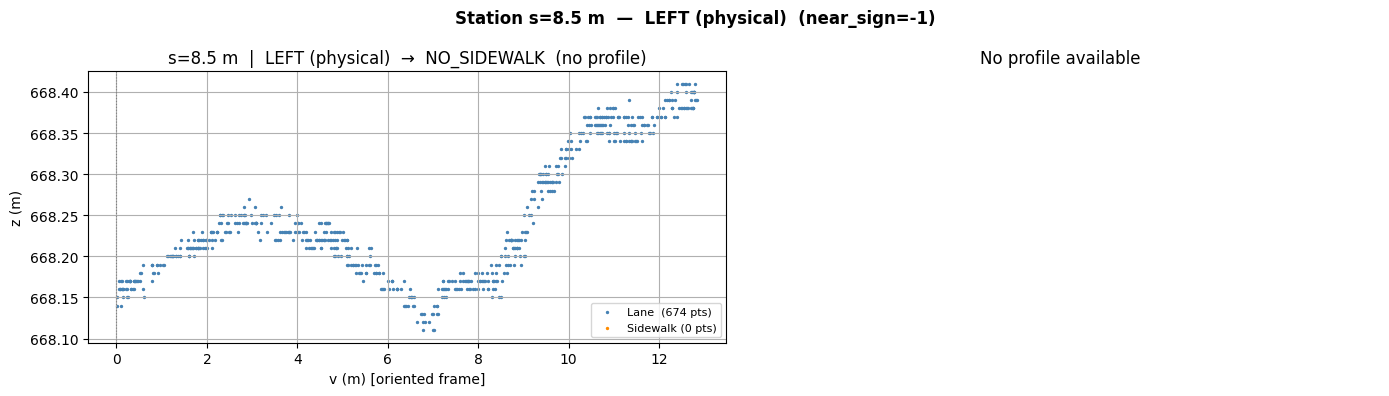

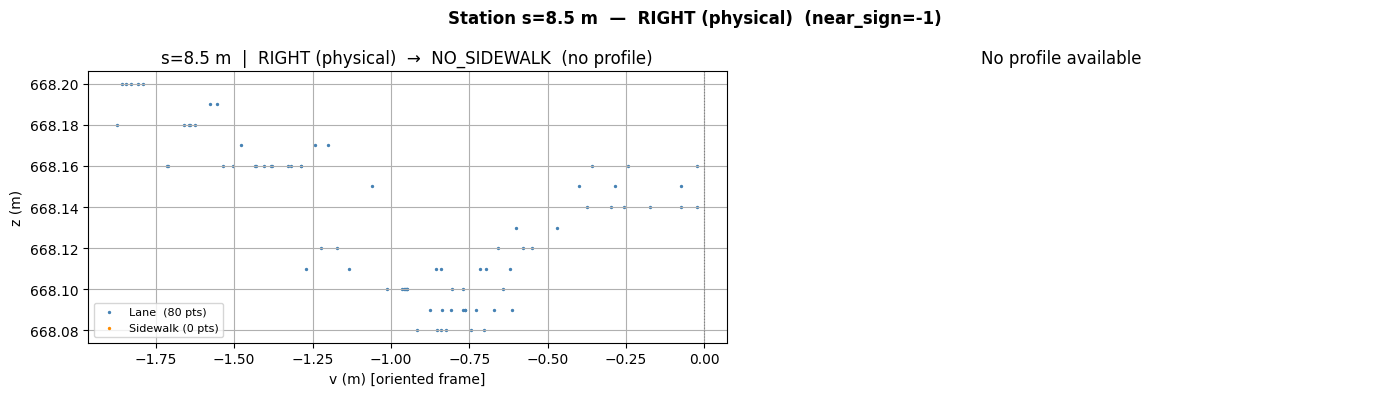

In [5]:
# ============================================================
# CELL 4b — Single-Station Debug Viewer
# ============================================================
# PURPOSE:
#   Inspect the full classification at any one station.
#   Reuses S_TARGET defined in Cell 1 — just change that value
#   and re-run this cell.
#
# REQUIRES: Cell 3 `results` + Cell 4 `classified` in memory.
# ============================================================

S_TARGET = 8.5

# ── Find the classified entry closest to S_TARGET ──────────
debug_idx = int(np.argmin(np.abs(
    np.array([r["s"] for r in classified]) - S_TARGET
)))
r = classified[debug_idx]

# ── Resolve physical side labels accounting for near_sign ──
near_sign = r["near_sign"]
if near_sign == 1.0:
    phys_R, phys_L = "RIGHT (physical)", "LEFT (physical)"
else:
    phys_R, phys_L = "LEFT (physical)",  "RIGHT (physical)"

print(f"Inspecting station s={r['s']:.2f} m  (requested S_TARGET={S_TARGET} m)")
print(f"  {phys_R} → {r['class_R']}")
print(f"  {phys_L} → {r['class_L']}")
print(f"\n  {phys_R} meta: {r['meta_R']}")
print(f"  {phys_L} meta: {r['meta_L']}")

# ── Plot both sides ─────────────────────────────────────────
for side in ("R", "L"):
    vl, zl = r["v_lane"], r["z_lane"]
    vs, zs = r["v_side"], r["z_side"]
    dbg    = r[f"dbg_{side}"]
    cls    = r[f"class_{side}"]
    meta   = r[f"meta_{side}"]

    mask_l = (vl >= 0) if side == "R" else (vl <= 0)
    mask_s = (vs >= 0) if side == "R" else (vs <= 0)

    # Physical side label for this plot
    phys_side = phys_R if side == "R" else phys_L

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left panel — raw scatter + smoothed profile + kinks
    ax = axes[0]
    ax.scatter(vl[mask_l], zl[mask_l], s=2, c="steelblue",  label=f"Lane  ({mask_l.sum()} pts)")
    ax.scatter(vs[mask_s], zs[mask_s], s=2, c="darkorange", label=f"Sidewalk ({mask_s.sum()} pts)")

    if dbg is not None:
        ax.plot(dbg["v_ctr"], dbg["z_s"], lw=2, c="black",  label="Smoothed")
        ax.axvline(dbg["v0"], ls="--", c="red",   lw=1.5,   label=f"kink v0={dbg['v0']:.2f} m")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5,   label=f"kink v1={dbg['v1']:.2f} m")
        dz    = meta.get("dz_m",   np.nan)
        slope = meta.get("slope",  np.nan)
        width = meta.get("transition_width_m", np.nan)
        ax.set_title(
            f"s={r['s']:.1f} m  |  {phys_side}  →  {cls}\n"
            f"dz={dz:.3f} m   slope={slope:.3f}   width={width:.2f} m"
        )
    else:
        ax.set_title(f"s={r['s']:.1f} m  |  {phys_side}  →  {cls}  (no profile)")

    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.set_xlabel("v (m) [oriented frame]"); ax.set_ylabel("z (m)")
    ax.legend(fontsize=8); ax.grid(True)

    # Right panel — second derivative (kink detector)
    ax2 = axes[1]
    if dbg is not None:
        ax2.plot(dbg["v_ctr"], dbg["d2"], c="purple", lw=1.5)
        ax2.axvline(dbg["v0"], ls="--", c="red",   lw=1.5, label=f"v0={dbg['v0']:.2f}")
        ax2.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"v1={dbg['v1']:.2f}")
        ax2.axhline(0, color="grey", lw=0.8)
        ax2.set_title("Second derivative d²z/dv²  (kink detector)")
        ax2.set_xlabel("v (m)"); ax2.set_ylabel("d²z/dv²")
        ax2.legend(fontsize=8); ax2.grid(True)
    else:
        ax2.set_title("No profile available")
        ax2.axis("off")

    plt.suptitle(f"Station s={r['s']:.1f} m  —  {phys_side}  (near_sign={near_sign:+.0f})",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()

In [6]:
# ============================================================
# CELL 5 — Export to CloudCompare + Human-Readable CSV
# ============================================================
# PURPOSE:
#   Two export files per run:
#
#   A) Trajectory-point cloud  (*_traj_CC.asc)
#      One point per station, placed at the trajectory XY,
#      colored by the dominant class (LEFT or RIGHT, whichever
#      has higher priority).  Use this to see the corridor
#      classification at a glance in CloudCompare.
#
#   B) Full sidewalk point cloud  (*_sidewalk_CC.asc)
#      Every sidewalk point from every station, back-projected
#      to real-world XY using  p + v_raw * n_hat.
#      Each point carries its class color.
#      Use this to see exactly which physical sidewalk areas
#      were classified as ramps vs curbs.
#
# REQUIRES: Cell 4 `classified` list in memory.
#
# OUTPUTS:
#   <traj_base>_traj_CC.asc          CloudCompare trajectory points
#   <traj_base>_traj.csv             Human-readable trajectory CSV
#   <traj_base>_sidewalk_CC.asc      CloudCompare sidewalk points
#   <traj_base>_sidewalk.csv         Human-readable sidewalk CSV
# ============================================================

import pandas as pd

# ─────────────────────────────────────────
# CLASS ENCODING
# ─────────────────────────────────────────

CLASS_CODE = {
    "RAMP":              0,
    "CURB_NO_RAMP":      1,
    "SEPARATED_NO_RAMP": 2,
    "NO_SIDEWALK":       3,
    "UNKNOWN":           4,
}

CLASS_COLOR = {
    "RAMP":              (0,   210,   0),   # bright green
    "CURB_NO_RAMP":      (255, 140,   0),   # orange
    "SEPARATED_NO_RAMP": (0,   100, 255),   # blue
    "NO_SIDEWALK":       (220,  50,  50),   # red
    "UNKNOWN":           (180, 180, 180),   # grey
}

# Lower index = higher priority when picking dominant color
PRIORITY = {name: i for i, name in enumerate(CLASS_CODE)}

INV_MAP  = {v: k for k, v in CLASS_CODE.items()}

def rgb_to_hex(r, g, b):
    return f"#{r:02X}{g:02X}{b:02X}"

def dominant_class(class_R: str, class_L: str) -> str:
    """
    Return whichever side has the higher-priority class.
    Priority: RAMP > CURB_NO_RAMP > SEPARATED_NO_RAMP > NO_SIDEWALK > UNKNOWN

    Example
    -------
    >>> dominant_class("CURB_NO_RAMP", "RAMP")
    'RAMP'
    """
    if PRIORITY.get(class_R, 99) <= PRIORITY.get(class_L, 99):
        return class_R
    return class_L

print("Class encoding:")
for name, code in CLASS_CODE.items():
    r, g, b = CLASS_COLOR[name]
    print(f"  {code} = {name:22s}  RGB({r:3d},{g:3d},{b:3d})  {rgb_to_hex(r,g,b)}")

# ─────────────────────────────────────────
# Try to get Z from trajectory CSV
# ─────────────────────────────────────────
cand_z = ["z", "Z", "alt", "altitude", "elevation",
          "Elevation", "height", "Height", "utm_z"]
zcol   = next((c for c in cand_z if c in dfT.columns), None)
traj_z = dfT[zcol].to_numpy(float) if zcol else None
print(f"\nTrajectory Z column: '{zcol}'" if zcol else "\nNo Z column — using z=0.0 for trajectory points")

# ─────────────────────────────────────────
# A) TRAJECTORY POINT EXPORT
# ─────────────────────────────────────────
traj_rows = []

for r in classified:
    traj_idx = int(np.argmin(np.abs(s - r["s"])))
    tx, ty   = traj_xy[traj_idx]
    tz       = float(traj_z[traj_idx]) if traj_z is not None else 0.0

    class_R  = r["class_R"]
    class_L  = r["class_L"]
    dom      = dominant_class(class_R, class_L)
    cr, cg, cb = CLASS_COLOR.get(dom, CLASS_COLOR["UNKNOWN"])

    traj_rows.append({
        "//X":         tx,
        "Y":           ty,
        "Z":           tz,
        "R":           cr,
        "G":           cg,
        "B":           cb,
        "s_m":         round(r["s"], 3),
        "class_RIGHT": CLASS_CODE.get(class_R, 4),
        "class_LEFT":  CLASS_CODE.get(class_L, 4),
        "label_R":     class_R,
        "label_L":     class_L,
        "dominant":    dom,
        "hex_R":       rgb_to_hex(*CLASS_COLOR.get(class_R, CLASS_COLOR["UNKNOWN"])),
        "hex_L":       rgb_to_hex(*CLASS_COLOR.get(class_L, CLASS_COLOR["UNKNOWN"])),
    })

df_traj = pd.DataFrame(traj_rows)

# ─────────────────────────────────────────
# B) FULL SIDEWALK POINT EXPORT
# ─────────────────────────────────────────
sw_rows = []

for r in classified:
    p         = r["p"]
    n_hat     = r["n_hat"]
    near_sign = r["near_sign"]
    vs        = r["v_side"]
    zs        = r["z_side"]

    # When near_sign = -1, the orient flip swapped physical sides.
    # Classifier "RIGHT" (v>=0) = physical LEFT, and vice versa.
    # So we swap the side labels to restore physical meaning.
    if near_sign == 1.0:
        side_assignments = [
            ("RIGHT", r["class_R"], vs >= 0),
            ("LEFT",  r["class_L"], vs <= 0),
        ]
    else:
        side_assignments = [
            ("LEFT",  r["class_R"], vs >= 0),   # oriented-RIGHT = physical-LEFT
            ("RIGHT", r["class_L"], vs <= 0),   # oriented-LEFT  = physical-RIGHT
        ]

    for side_label, class_name, mask in side_assignments:
        if mask.sum() == 0:
            continue

        v_sw    = vs[mask]
        z_sw    = zs[mask]
        v_raw   = v_sw * near_sign          # un-flip back to world orientation
        world_x = p[0] + v_raw * n_hat[0]
        world_y = p[1] + v_raw * n_hat[1]

        cr, cg, cb = CLASS_COLOR.get(class_name, CLASS_COLOR["UNKNOWN"])
        cls_int    = CLASS_CODE.get(class_name, 4)
        hex_col    = rgb_to_hex(cr, cg, cb)

        for wx, wy, wz, vs_val in zip(world_x, world_y, z_sw, v_sw):
            sw_rows.append({
                "x":     wx,
                "y":     wy,
                "z":     wz,
                "R":     cr,
                "G":     cg,
                "B":     cb,
                "s_m":   round(float(r["s"]), 3),
                "v_m":   round(float(vs_val), 4),
                "side":  side_label,
                "class": cls_int,
                "label": class_name,
                "color": hex_col,
            })

df_sw = pd.DataFrame(sw_rows)

# ─────────────────────────────────────────
# SAVE FILES
# ─────────────────────────────────────────
base = TRAJ_CSV.replace(".csv", "")

# --- Trajectory CloudCompare .asc ---
traj_cc  = base + "_traj_CC.asc"
traj_csv = base + "_traj.csv"

cc_cols = ["//X", "Y", "Z", "R", "G", "B", "s_m", "class_RIGHT", "class_LEFT"]
with open(traj_cc, "w") as f:
    f.write("//X Y Z R G B s_m class_RIGHT class_LEFT\n")
    df_traj[cc_cols].to_csv(f, sep=" ", index=False, header=False)

df_traj.to_csv(traj_csv, index=False)

# --- Sidewalk CloudCompare .asc ---
sw_cc  = base + "_sidewalk_CC.asc"
sw_csv = base + "_sidewalk.csv"

df_cc2 = df_sw[["x","y","z","R","G","B","s_m","v_m","side","class"]].copy()
df_cc2["side"] = df_cc2["side"].map({"RIGHT": 0, "LEFT": 1})
df_cc2 = df_cc2.rename(columns={"x": "//X"})

with open(sw_cc, "w") as f:
    f.write("//X Y Z R G B s_m v_m side class\n")
    df_cc2.to_csv(f, sep=" ", index=False, header=False)

df_sw.to_csv(sw_csv, index=False)

# ─────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────
print(f"\nTrajectory points : {len(df_traj):,}")
print(f"Sidewalk points   : {len(df_sw):,}")

print("\nSidewall class breakdown:")
for cls_int, grp in df_sw.groupby("class"):
    lbl = INV_MAP.get(cls_int, "UNKNOWN")
    cr, cg, cb = CLASS_COLOR.get(lbl, CLASS_COLOR["UNKNOWN"])
    print(f"  {cls_int} = {lbl:22s}  {len(grp):8,} pts  {rgb_to_hex(cr,cg,cb)}")

print(f"\nFiles saved:")
print(f"  {traj_cc}")
print(f"  {traj_csv}")
print(f"  {sw_cc}")
print(f"  {sw_csv}")

print("""
CloudCompare import instructions:
  File > Open > select either .asc file
  In the ASCII import dialog assign:
    col1=X  col2=Y  col3=Z  col4=R  col5=G  col6=B
    col7=scalar(s_m)  col8=scalar(v_m or class_RIGHT)
  Points are colored automatically by class via RGB channels.
  To re-color by scalar: Edit > Colors > From Scalar Field
""")

Class encoding:
  0 = RAMP                    RGB(  0,210,  0)  #00D200
  1 = CURB_NO_RAMP            RGB(255,140,  0)  #FF8C00
  2 = SEPARATED_NO_RAMP       RGB(  0,100,255)  #0064FF
  3 = NO_SIDEWALK             RGB(220, 50, 50)  #DC3232
  4 = UNKNOWN                 RGB(180,180,180)  #B4B4B4

Trajectory Z column: 'Z'

Trajectory points : 532
Sidewalk points   : 6,901

Sidewall class breakdown:
  0 = RAMP                         268 pts  #00D200
  3 = NO_SIDEWALK                   70 pts  #DC3232
  4 = UNKNOWN                    6,563 pts  #B4B4B4

Files saved:
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\20250506_R01_506_Trg_traj_CC.asc
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\20250506_R01_506_Trg_traj.csv
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\20250506_R01_506_Trg_sidewalk_CC.asc
  C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\03\20250506_R01_506_Trg_sidewalk.csv

CloudCompare import instructions:
  File > Open > select either .asc file
  In the 

In [ ]:
# Cell 6
# --- Save as LAS files ---
import laspy

def save_las(path: str, x, y, z, r, g, b):
    """
    Save points with RGB color to a LAS file (version 1.4, point format 2).

    Parameters
    ----------
    path    : output .las file path
    x, y, z : coordinate arrays
    r, g, b : color arrays (0–255)
    """
    header = laspy.LasHeader(point_format=2, version="1.4")
    las    = laspy.LasData(header=header)
    las.x  = np.asarray(x, dtype=float)
    las.y  = np.asarray(y, dtype=float)
    las.z  = np.asarray(z, dtype=float)
    # LAS point format 2 stores RGB as 16-bit (0–65535)
    # Scale 0–255 → 0–65535 by multiplying by 256
    las.red   = (np.asarray(r, dtype=np.uint16) * 256)
    las.green = (np.asarray(g, dtype=np.uint16) * 256)
    las.blue  = (np.asarray(b, dtype=np.uint16) * 256)
    las.write(path)
    print(f"  LAS saved → {path}  ({len(x):,} pts)")

# Trajectory LAS
traj_las = base + "_traj_CC.las"
save_las(
    traj_las,
    df_traj["//X"].to_numpy(),
    df_traj["Y"].to_numpy(),
    df_traj["Z"].to_numpy(),
    df_traj["R"].to_numpy(),
    df_traj["G"].to_numpy(),
    df_traj["B"].to_numpy(),
)

# Sidewalk LAS
sw_las = base + "_sidewalk_CC.las"
save_las(
    sw_las,
    df_sw["x"].to_numpy(),
    df_sw["y"].to_numpy(),
    df_sw["z"].to_numpy(),
    df_sw["R"].to_numpy(),
    df_sw["G"].to_numpy(),
    df_sw["B"].to_numpy(),
)

print(f"  {traj_las}")
print(f"  {sw_las}")